In [30]:
import torch
from torch import Tensor
from geodesic_toolbox.cometric import FunnelHessian, FunnelSoftAbs, FunnelScore, FunnelRanders, FunnelDualRanders
from geodesic_toolbox.samplers import ImplicitRHMCSampler, ImplicitFHMCUnbiased, ImplicitFHMCLegendre
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

In [31]:
beta = 0.9
alpha = 1
dim = 1                       # number of theta coordinates (total state dimension = dim + 1)
r_metric = FunnelSoftAbs(dim, alpha)
f_metric = FunnelRanders(dim, alpha=alpha, beta=beta)

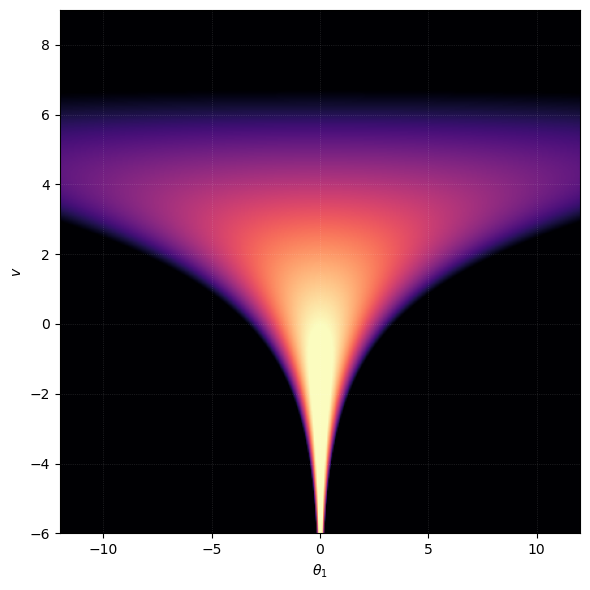

In [32]:
grid_fine = 400

# Plotting coordinates: theta_1 on the horizontal axis, v on the vertical axis.
xg = np.linspace(-12, 12, grid_fine)   # theta_1
yg = np.linspace(-6, 9, grid_fine)     # v
xx, yy = np.meshgrid(xg, yg)

# Marginal log-density of (v, theta_1) for Neal's funnel (one theta coordinate).
log_pi  = -yy**2 / 18 - 0.5 * yy - np.exp(-yy) / 2 * xx**2
vmax_pi = np.percentile(log_pi, 99)
vmin_pi = np.percentile(log_pi, 60)

fig, ax = plt.subplots(figsize=(6, 6))

im = ax.imshow(
    log_pi,
    origin="lower",
    extent=[xg.min(), xg.max(), yg.min(), yg.max()],
    cmap="magma",
    aspect="auto",
    vmin=vmin_pi,
    vmax=vmax_pi,
    zorder=0,
)

ax.grid(True, linestyle=":", linewidth=0.5, color="white", alpha=0.2)
ax.set_axisbelow(False)

ax.set_xlabel(r"$\theta_1$")
ax.set_ylabel("$v$")
ax.set_xlim(xg.min(), xg.max())
ax.set_ylim(yg.min(), yg.max())
plt.tight_layout()
plt.show()

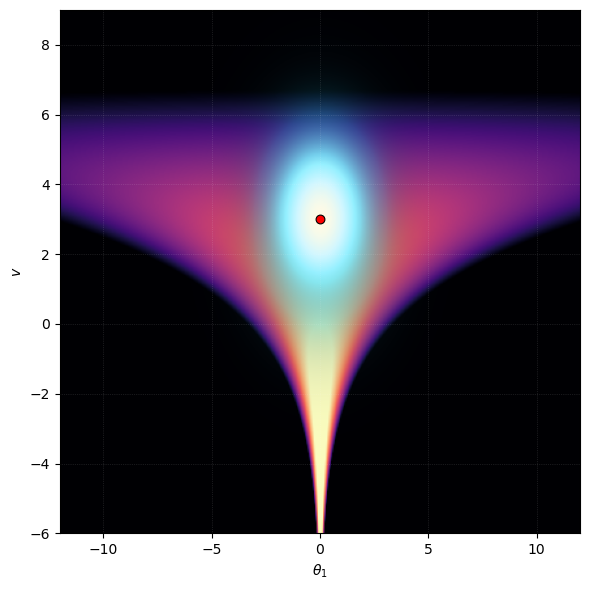

In [33]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.colors import LinearSegmentedColormap
from scipy.ndimage import gaussian_filter
from scipy.stats import multivariate_normal

# ======================================================================
# 1. Riemannian primal metric G(z) in the mouth of the funnel dist.
# ======================================================================
z = torch.tensor([[3.0, 0.0]])                       # state [v, theta_1]
G_z = r_metric.cometric_tensor(z)[0].detach().numpy()  # 2x2 in (v, theta) order

# Reorder from state coords (v, theta) to plotting coords (theta, v).
perm = [1, 0]
G_z_plot = G_z[np.ix_(perm, perm)]
z_plot = z[0].numpy()[perm]                          # [theta0, v0]

# The ellipse is tiny at this plot scale, so magnify it purely for visibility.
visual_scale = 2.0
G_z_display = visual_scale * G_z_plot

gaussian = multivariate_normal(mean=z_plot, cov=G_z_display)
pdf_vals = gaussian.pdf(np.stack([xx, yy], axis=-1))

# 1/2/3-sigma levels, exact for a 2D Gaussian: pdf = peak * exp(-k**2/2)
det_G = np.linalg.det(G_z_display)
peak = 1.0 / (2 * np.pi * np.sqrt(det_G))
levels = [peak * np.exp(-k ** 2 / 2) for k in (3, 2, 1)]

# ======================================================================
# 2. Composite the density background + glowing metric cloud into one
#    rgb image, so a dark "moat" can lift the cloud off the bright ridge.
# ======================================================================
extent = [xg.min(), xg.max(), yg.min(), yg.max()]

# -- 2a. density background (magma) --
n_pi = np.clip((log_pi - vmin_pi) / (vmax_pi - vmin_pi), 0, 1)
img = cm.magma(n_pi)[..., :3].copy()

# -- 2b. the metric ellipse as a luminous cyan cloud --
cloud = LinearSegmentedColormap.from_list("cloud", [
    (0.00, "#0a3a45"), (0.25, "#1aa6c4"), (0.60, "#74ecff"),
    (0.85, "#d2f7ff"), (1.00, "#fffbe6"),                 # yellow-white hot core
])
d = pdf_vals / pdf_vals.max()
core = d ** 0.6
halo = 0.6 * gaussian_filter(d, 4.0) + 0.4 * gaussian_filter(d, 12.0)   # wide glow
halo /= halo.max() + 1e-9

# contrast moat: darken the ring around the cloud (in the halo, not the core)
moat = np.clip(halo - core, 0, 1)
img = img * (1 - 0.55 * moat[..., None])

# over-composite the cloud (strong core alpha => covers the ridge, not just tints it)
cloud_rgb = cloud(np.clip(core, 0, 1))[..., :3]
a_cloud = np.clip(0.95 * d ** 0.5 + 0.55 * halo, 0, 1)[..., None]
img = np.clip(img * (1 - a_cloud) + cloud_rgb * a_cloud, 0, 1)

# ======================================================================
# 3. Draw
# ======================================================================
fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(img, origin="lower", extent=extent, aspect="auto", zorder=0)

ax.scatter(0, 3, color="red", s=40, edgecolor="black", linewidth=0.8, zorder=5)

ax.grid(True, linestyle=":", linewidth=0.5, color="white", alpha=0.2)
ax.set_axisbelow(False)
ax.set_xlabel(r"$\theta_1$"); ax.set_ylabel("$v$")
ax.set_xlim(xg.min(), xg.max()); ax.set_ylim(yg.min(), yg.max())
plt.tight_layout()
plt.show()

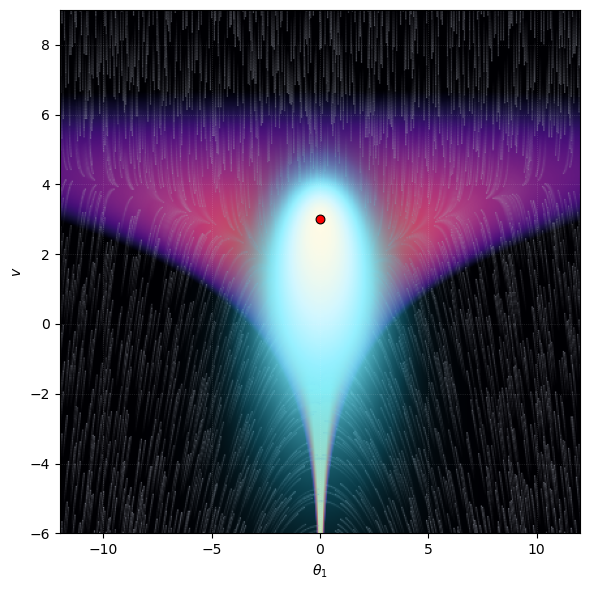

In [34]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.colors import LinearSegmentedColormap
from scipy.ndimage import gaussian_filter

# ======================================================================
# 1. Finslerian velocity density  exp(-1/2 F_z^2(v))   (unnormalized)
# ======================================================================
z = torch.tensor([[3.0, 0.0]])                       # state [v, theta_1]
v0, theta0 = z[0, 0].item(), z[0, 1].item()

# Velocity vectors in STATE coords [dv, dtheta]; plot-x is theta (xx), plot-y is v (yy).
v_flat = torch.tensor(
    np.stack([yy.ravel() - v0, xx.ravel() - theta0], axis=1),
    dtype=torch.float32,
)
z_flat = z.repeat(v_flat.shape[0], 1)
with torch.no_grad():
    F_vals = f_metric(z_flat, v_flat)

# F is positively 1-homogeneous, so evaluating at v / sqrt(visual_scale)
# draws the true density magnified by visual_scale.
F_vals_display = F_vals / np.sqrt(visual_scale)
density_F = torch.exp(-0.5 * F_vals_display ** 2).numpy().reshape(xx.shape)

# ======================================================================
# 2. Randers drift field  beta * omega(z)  ->  sparse OLIC texture
# ======================================================================
grid_field = xx.shape[0]
# Grid points in STATE coords [v, theta] = [yy, xx].
pts_field = torch.tensor(np.stack([yy.ravel(), xx.ravel()], axis=1), dtype=torch.float32)
with torch.no_grad():
    drift_field = f_metric.beta * f_metric.omega(pts_field)
# Map drift to plotting axes: U = theta-component (col 1), V = v-component (col 0).
U = drift_field[:, 1].numpy().reshape(xx.shape)
V = drift_field[:, 0].numpy().reshape(xx.shape)
speed = np.sqrt(U ** 2 + V ** 2)


def sparse_olic(U, V, density=0.018, n_steps=46, step=0.7, seed=0, decay=0.9):
    """Sparse oriented LIC: droplets smeared into comets that point along the flow.
       Pass U, V in PIXEL units so strokes match the on-screen direction."""
    H, W = U.shape
    mag = np.hypot(U, V); mag[mag == 0] = 1.0
    u, v = U / mag, V / mag
    rng = np.random.default_rng(seed)
    tex = np.zeros((H, W))
    flat = rng.integers(0, H * W, int(density * H * W))
    tex.flat[flat] = rng.uniform(0.6, 1.0, flat.size)
    ys, xs = np.mgrid[0:H, 0:W]

    def sample(f, x, y):
        x0 = np.clip(np.floor(x).astype(int), 0, W - 1); y0 = np.clip(np.floor(y).astype(int), 0, H - 1)
        x1 = np.clip(x0 + 1, 0, W - 1); y1 = np.clip(y0 + 1, 0, H - 1)
        fx, fy = x - x0, y - y0
        return (f[y0, x0] * (1 - fx) * (1 - fy) + f[y0, x1] * fx * (1 - fy)
                + f[y1, x0] * (1 - fx) * fy + f[y1, x1] * fx * fy)

    inten = np.zeros((H, W))
    x = xs.astype(float).copy(); y = ys.astype(float).copy()
    for k in range(n_steps):
        w = (1 - k / n_steps) ** decay
        inten = np.maximum(inten, w * sample(tex, x, y))
        x -= step * sample(u, x, y); y -= step * sample(v, x, y)
    return inten / (inten.max() + 1e-9)


dx = (xg.max() - xg.min()) / (grid_field - 1)
dy = (yg.max() - yg.min()) / (grid_field - 1)
inten = sparse_olic(U / dx, V / dy)
s = np.clip(speed / np.percentile(speed, 98), 0, 1)        # speed -> stroke lightness

# ======================================================================
# 3. Composite everything into ONE rgb image, so we can carve a dark
#    "moat" around the velocity cloud and let it glow off the ridge.
# ======================================================================
extent = [xg.min(), xg.max(), yg.min(), yg.max()]

# -- 3a. density background (magma). --
n_pi = np.clip((log_pi - vmin_pi) / (vmax_pi - vmin_pi), 0, 1)
img = cm.magma(n_pi)[..., :3].copy()

# -- 3b. OLIC drift texture over it (sober slate-grey, only lightness tracks speed) --
field_rgb = np.array([0.82, 0.84, 0.90]) * (0.8 + 0.2 * s[..., None])
a_field = np.clip(inten * 0.5, 0, 1)[..., None]
img = img * (1 - a_field) + field_rgb * a_field

# -- 3c. the velocity distribution as a luminous cloud --
cloud = LinearSegmentedColormap.from_list("cloud", [
    (0.00, "#0a3a45"), (0.25, "#1aa6c4"), (0.60, "#74ecff"),
    (0.85, "#d2f7ff"), (1.00, "#fffbe6"),                 # yellow-white hot core
])
d = density_F / density_F.max()
core = d ** 0.6
halo = 0.6 * gaussian_filter(d, 4.0) + 0.4 * gaussian_filter(d, 12.0)   # wide glow
halo /= halo.max() + 1e-9

# contrast moat: darken the ring around the cloud (present in halo, absent in core)
moat = np.clip(halo - core, 0, 1)
img = img * (1 - 0.55 * moat[..., None])

# over-composite the cloud (strong core alpha => it covers the ridge, not just tints it)
cloud_rgb = cloud(np.clip(core, 0, 1))[..., :3]
a_cloud = np.clip(0.95 * d ** 0.5 + 0.55 * halo, 0, 1)[..., None]
img = np.clip(img * (1 - a_cloud) + cloud_rgb * a_cloud, 0, 1)

# ======================================================================
# 4. Draw
# ======================================================================
fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(img, origin="lower", extent=extent, aspect="auto", zorder=0)

ax.scatter(theta0, v0, color="red", s=40, edgecolor="black", linewidth=0.8, zorder=5)

ax.grid(True, linestyle=":", linewidth=0.5, color="white", alpha=0.2)
ax.set_axisbelow(False)
ax.set_xlabel(r"$\theta_1$"); ax.set_ylabel("$v$")
ax.set_xlim(xg.min(), xg.max()); ax.set_ylim(yg.min(), yg.max())
plt.tight_layout()
plt.show()